In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('spam.csv')

In [5]:
df.sample(5)

,Category,Message
1846,ham,Hi. || Do u want | to join me with sts later? ...
3653,ham,"Probably not, still going over some stuff here"
5312,ham,Here got ur favorite oyster... N got my favori...
3684,ham,When did i use soc... I use it only at home......
4854,ham,I'm fine. Hope you are also


In [6]:
df.shape

(5572, 2)

## 1. DATA CLEANING

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [8]:
df.sample(5)

,Category,Message
4937,ham,K..k.:)congratulation ..
1960,ham,Howz that persons story
5379,ham,Somebody set up a website where you can play h...
1308,spam,"Get 3 Lions England tone, reply lionm 4 mono o..."
3598,spam,Congratulations YOU'VE Won. You're a Winner in...


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['Category'] = encoder.fit_transform(df['Category'])

In [11]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
#CHECK MISSING VALUES
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [13]:
#Check Duplicate Values
df.duplicated().sum()

np.int64(415)

In [14]:
# Remove duplicate values
df = df.drop_duplicates(keep='first')

In [15]:
#Check Duplicate Values again after drop
df.duplicated().sum()

np.int64(0)

## 2. EDA 

In [16]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df['Category'].value_counts()

Category
0    4516
1     641
Name: count, dtype: int64

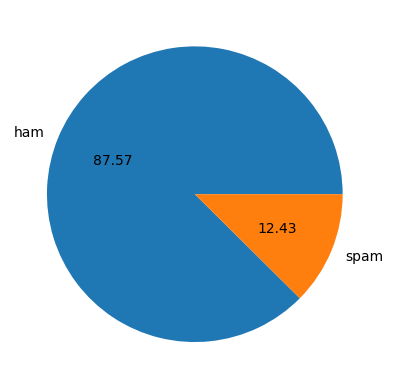

In [18]:
import matplotlib.pyplot as plt
plt.pie(df['Category'].value_counts(), labels= ['ham','spam'], autopct= "%0.2f" )
plt.show()

In [19]:
## Data is imbalanced

In [20]:
import nltk

In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aimon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Aimon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
df['num_characters'] = df['Message'].apply(len)

In [23]:
df.head()

,Category,Message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
#num of words
df['num_words']= df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df.head()

,Category,Message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
#num of sentences
df['num_sentences']= df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,Category,Message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.560791,1.969750
std,58.382922,13.406330,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
## Not Spam or Ham Messages
df[df['Category']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,17.268158,1.827724
std,56.708301,13.588513,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
## Spam Messages
df[df['Category']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,641.000000,641.000000,641.000000
mean,137.118565,27.667707,2.970359
std,30.399707,7.103501,1.485575
min,7.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


In [31]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

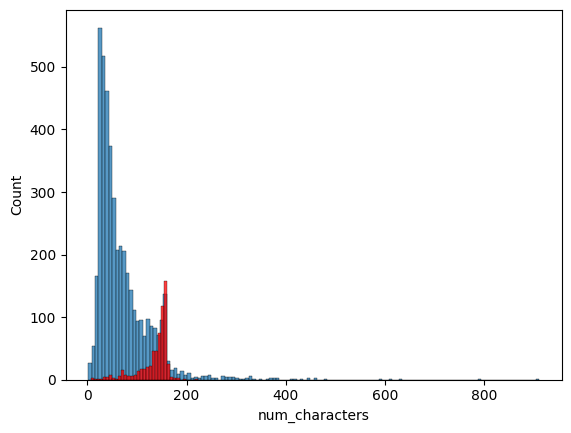

In [33]:
sns.histplot(df[df['Category'] == 0]['num_characters'])  ##Not Spam /Ham
sns.histplot(df[df['Category'] == 1]['num_characters'], color='red') ## Spam

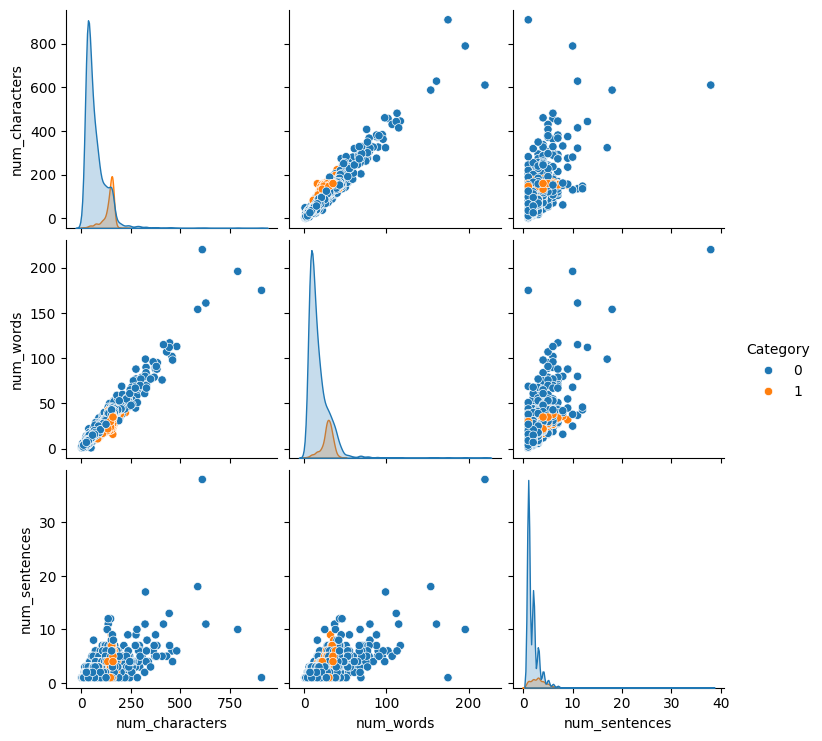

In [34]:
sns.pairplot(df,hue='Category')

## 3. DATA PREPROCESSING
i. Lower case
ii. Tokenization
iii. Removing special characters
iv. Remove stop words and puntuation
v. Stemming

In [35]:
def transform_text(text):                 
    text = text.lower()       #LOWER CASE
    text = nltk.word_tokenize(text)        #TOKENIZATION

    y = []
    for i in text:                  #Remove Special characters (e.g. %%)
        if i.isalnum():
            y.append(i)

    text = y[:]                       #Remove Stopwords and Punctuation
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text= y[:]        #Stemming
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
        
    return  " ".join(y)

In [36]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aimon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
from nltk.corpus import stopwords
import string

In [40]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [41]:
df['Message'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [42]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [43]:
df['transformed_Message'] = df['Message'].apply(transform_text)

In [44]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_Message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [45]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color= 'white') 

In [52]:
spam_wc = wc.generate(df[df['Category'] == 1]['transformed_Message'].str.cat(sep= " "))

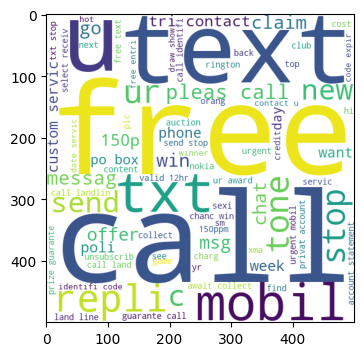

In [53]:
plt.figure(figsize=(10,4))
plt.imshow(spam_wc)

In [54]:
ham_wc = wc.generate(df[df['Category'] == 0]['transformed_Message'].str.cat(sep= " "))

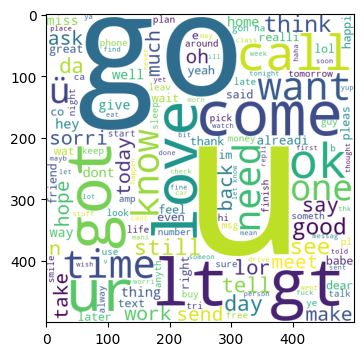

In [55]:
plt.figure(figsize=(10,4))
plt.imshow(ham_wc)

In [56]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_Message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [57]:
spam_corpus=[]
for msg in df[df['Category'] == 1]['transformed_Message'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [58]:
len(spam_corpus)

9781

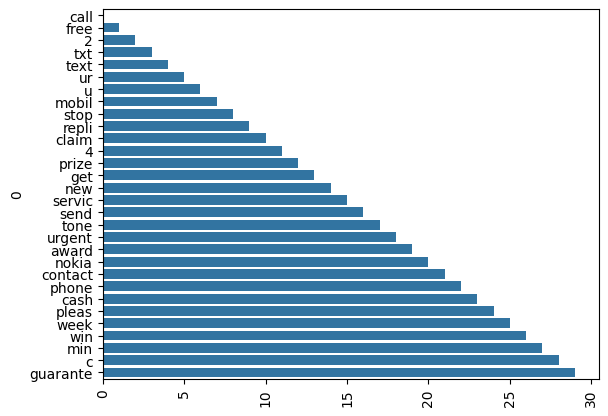

In [59]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus) .most_common(30))[0]),(pd.DataFrame(Counter(spam_corpus) .most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [60]:
ham_corpus=[]
for msg in df[df['Category'] == 0]['transformed_Message'].tolist():
    for words in msg.split():
        ham_corpus.append(words)

In [61]:
len(ham_corpus)

35942

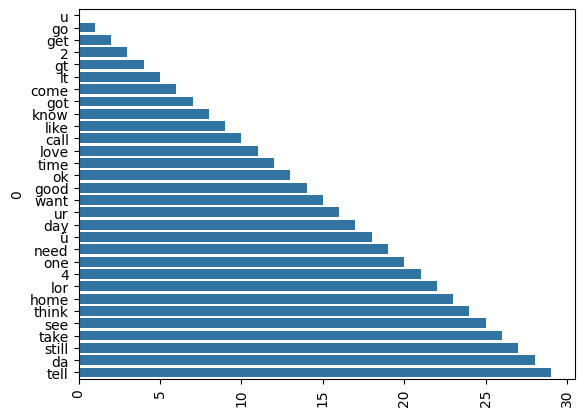

In [62]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus) .most_common(30))[0]),(pd.DataFrame(Counter(ham_corpus) .most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [63]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_Message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## 4. MODEL BUILDING

In [205]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [206]:
#X = cv.fit_transform(df['transformed_Message']).toarray()     ##using CountVectorizer
X = tfidf.fit_transform(df['transformed_Message']).toarray()

In [207]:
#from sklearn.preprocessing import MinMaxScaler   #Scaling
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [208]:
# appending the num_character col to X
X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [209]:
X.shape

(5157, 3001)

In [210]:
y = df['Category'].values

In [211]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5157,))

In [212]:
from sklearn.model_selection import train_test_split

In [213]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [214]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [215]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [216]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8827519379844961
[[800 105]
 [ 16 111]]
0.5138888888888888


In [217]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))           #using cv precision_score was 0.97 now with tfidf it improves..

0.939922480620155
[[905   0]
 [ 62  65]]
1.0


In [218]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9825581395348837
[[903   2]
 [ 16 111]]
0.9823008849557522


In [219]:
#MultinomialNB gives best results for precision with tfidf so select it

In [220]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn. ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [221]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver= 'liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [222]:
clfs = {
'SVC' : svc,
'KN': knc,
'NB': mnb,
'DT': dtc,
'LR' :lrc,
'RF': rfc,
'AdaBoost': abc,
'BGC' : bc,
'ETC': etc,
'GBDT': gbdt,
'xgb': xgb
}

In [223]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    return accuracy, precision

In [225]:
train_classifier(svc,X_train,y_train,X_test,y_test)

C:\Users\Aimon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.876937984496124, 0.0)

In [229]:
from sklearn.metrics import accuracy_score, precision_score
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    

C:\Users\Aimon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


For  SVC
Accuracy -  0.876937984496124
Precision -  0.0
For  KN
Accuracy -  0.9282945736434108
Precision -  0.7054263565891473
For  NB
Accuracy -  0.939922480620155
Precision -  1.0
For  DT
Accuracy -  0.9573643410852714
Precision -  0.9368421052631579
For  LR
Accuracy -  0.9641472868217055
Precision -  0.9591836734693877
For  RF
Accuracy -  0.9767441860465116
Precision -  1.0
For  AdaBoost
Accuracy -  0.9515503875968992
Precision -  0.9052631578947369
For  BGC
Accuracy -  0.9718992248062015
Precision -  0.9537037037037037
For  ETC
Accuracy -  0.9796511627906976
Precision -  1.0
For  GBDT
Accuracy -  0.9554263565891473
Precision -  0.9354838709677419
For  xgb
Accuracy -  0.9709302325581395
Precision -  0.970873786407767


In [230]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [231]:
performance_df

,Algorithm,Accuracy,Precision
2,NB,0.939922,1.000000
8,ETC,0.979651,1.000000
5,RF,0.976744,1.000000
10,xgb,0.970930,0.970874
4,LR,0.964147,0.959184
7,BGC,0.971899,0.953704
3,DT,0.957364,0.936842
9,GBDT,0.955426,0.935484
6,AdaBoost,0.951550,0.905263
1,KN,0.928295,0.705426


In [232]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [233]:
performance_df1

,Algorithm,variable,value
0,NB,Accuracy,0.939922
1,ETC,Accuracy,0.979651
2,RF,Accuracy,0.976744
3,xgb,Accuracy,0.970930
4,LR,Accuracy,0.964147
5,BGC,Accuracy,0.971899
6,DT,Accuracy,0.957364
7,GBDT,Accuracy,0.955426
8,AdaBoost,Accuracy,0.951550
9,KN,Accuracy,0.928295


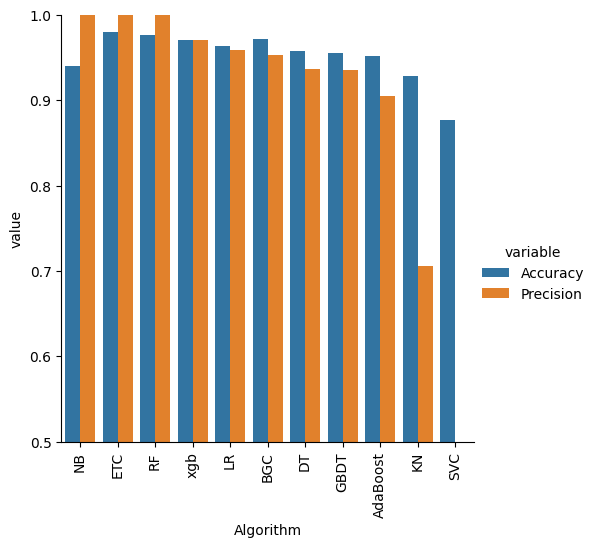

In [234]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [235]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [236]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [237]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [238]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [239]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [243]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [244]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,NB,0.939922,1.000000,0.939922,1.000000,0.939922,1.000000,0.939922,1.000000
1,ETC,0.979651,1.000000,0.979651,1.000000,0.979651,1.000000,0.979651,1.000000
2,RF,0.976744,1.000000,0.976744,1.000000,0.976744,1.000000,0.976744,1.000000
3,xgb,0.970930,0.970874,0.970930,0.970874,0.970930,0.970874,0.970930,0.970874
4,LR,0.964147,0.959184,0.964147,0.959184,0.964147,0.959184,0.964147,0.959184
5,BGC,0.971899,0.953704,0.971899,0.953704,0.971899,0.953704,0.971899,0.953704
6,DT,0.957364,0.936842,0.957364,0.936842,0.957364,0.936842,0.957364,0.936842
7,GBDT,0.955426,0.935484,0.955426,0.935484,0.955426,0.935484,0.955426,0.935484
8,AdaBoost,0.951550,0.905263,0.951550,0.905263,0.951550,0.905263,0.951550,0.905263
9,KN,0.928295,0.705426,0.928295,0.705426,0.928295,0.705426,0.928295,0.705426


In [245]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [246]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [247]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [248]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.937015503875969
Precision 1.0


In [249]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [252]:
from sklearn.ensemble import StackingClassifier

In [255]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [256]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9815891472868217
Precision 0.9655172413793104


In [257]:
#Accuracy remains same after using all the classifiers as with the Multinomial Bayes theorm so at last we'll use MNB for Model

In [258]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))